<a href="https://colab.research.google.com/github/vitor-laudares/Trabalho-Final-Py_Stellantis/blob/main/trabalho_final_py_stellantis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Trabalho final da disciplina de programação em Python

Alunos:

Anna Beatriz

Joao Pedro

Matheus Rocha

Pedro Henrique

Vitor Laudares


---




## Tema: Emissão de CO2 por veículos

O dataset escolhido, apresenta mais de 7 mil carros de diferentes montadoras. As características presentes são:

Make

Model

Vehicle Class

Engine Size(L)

Cylinders

Transmission

Fuel Type

Fuel Consumption City (L/100 km)

Fuel Consumption Hwy (L/100 km)

Fuel Consumption Comb (L/100 km)

Fuel Consumption Comb (mpg)

CO2 Emissions(g/km)

Vizualizações:



Desafio:
1) filtragem dos elementos do dataset. Muitas informaçãos pra objetivos muito espeficos
2) encontrar o significado de cada legenda,  além de adequar de forma "limpa" em cada grafica

Maiores erros:
* Na hora de plotar (top 20 veiculos com menos emissao de co2) tinha carro com o mesmo nome mas com caracteristicas diferentes. No meio do desenvolvimento dos gaficos foi necessario refazer todos retirando a duplicidade

* tipos de cambio: tentamos alterar direto no dataframe mas esquemos do numero de marchas. O  nome podia ficar muito grande, com isso foi necessario inserir uma legenda para indicar de forma clara
lições

1) controle de versão foi essencial pois precisamos de voltar atrá >>> importante usar o github para fazer as alterações
2) estrutura condicional, listas e dicionarios foram essenciais
3) bibliotecas inteligentes que fazem coisas muito avançadas com pouco esforço manual.  
4) Laços de repetição, como o for foram essenciais para o desenvolvimento.
5) comentar codigo é de grande ajuda




In [1]:
# Imports e carregamento do arquivo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Cria um dataframe a partir do dataset escolhido
data = pd.read_csv('co2.csv')

# No data.info, vemos que não existem buracos nem dados faltantes
# data.info()


In [2]:
# Total de carros antes de remover as duplicatas
total_antes = len(data)

# Cria um dataframe temporário
data_temp = data.copy()

# Percorre cada coluna e transforma tudo para minúsculo
for coluna in data_temp.columns:
    data_temp[coluna] = data_temp[coluna].astype(str).str.lower()

# Encontra os dados duplicados
duplicatas = data_temp.duplicated()

# Remove as duplicatas do dataframe original
data = data[~duplicatas]

# Print de quantos dados foram removidos
removidos = total_antes - len(data)
print(f"Foram removidos {removidos} registros duplicados.")


# Conversão de L/100km para km/L
colunas_consumo = ['Fuel Consumption City (L/100 km)',
                   'Fuel Consumption Hwy (L/100 km)',
                   'Fuel Consumption Comb (L/100 km)']

# Percorre todas as colunas e faz a conversão, além de renomear também
for coluna in colunas_consumo:
    data[coluna] = 100 / data[coluna]
    data.rename(columns={coluna: coluna.replace('L/100 km', 'km/L')}, inplace=True)
# data.info()


# Conversão dos Códigos de combustível, para melhorar a legibilidade
lista_combustiveis = []
for sigla in data['Fuel Type']:
    if sigla == 'D':
        lista_combustiveis.append('Diesel')
    elif sigla == 'E':
        lista_combustiveis.append('Etanol')
    elif sigla == 'N':
        lista_combustiveis.append('Gás Natural')
    elif sigla == 'X':
        lista_combustiveis.append('Gasolina Comum')
    elif sigla == 'Z':
        lista_combustiveis.append('Gasolina Premium')
data['Fuel Type'] = lista_combustiveis


# Junção das marcas em grupos
lista_marcas = data['Make'].unique()
stellantis_marcas = ['CHRYSLER', 'DODGE', 'FIAT', 'JEEP', 'RAM', 'ALFA ROMEO', 'MASERATI']
data.loc[data['Make'] == 'SRT', 'Make'] = 'DODGE'
gm_marcas = ['CHEVROLET', 'BUICK', 'CADILLAC', 'GMC']
vw_marcas = ['VOLKSWAGEN', 'AUDI', 'PORSCHE', 'LAMBORGHINI', 'BENTLEY']
toyota_marcas = ['TOYOTA', 'LEXUS']
hyundai_marcas = ['HYUNDAI', 'KIA', 'GENESIS']
bmw_marcas = ['BMW', 'MINI', 'ROLLS-ROYCE']
ford_marcas = ['FORD', 'LINCOLN']
honda_marcas = ['HONDA', 'ACURA']

data['Model'] = data['Model'].str.upper().str.strip()


Foram removidos 1394 registros duplicados.


Boxplot por grupos

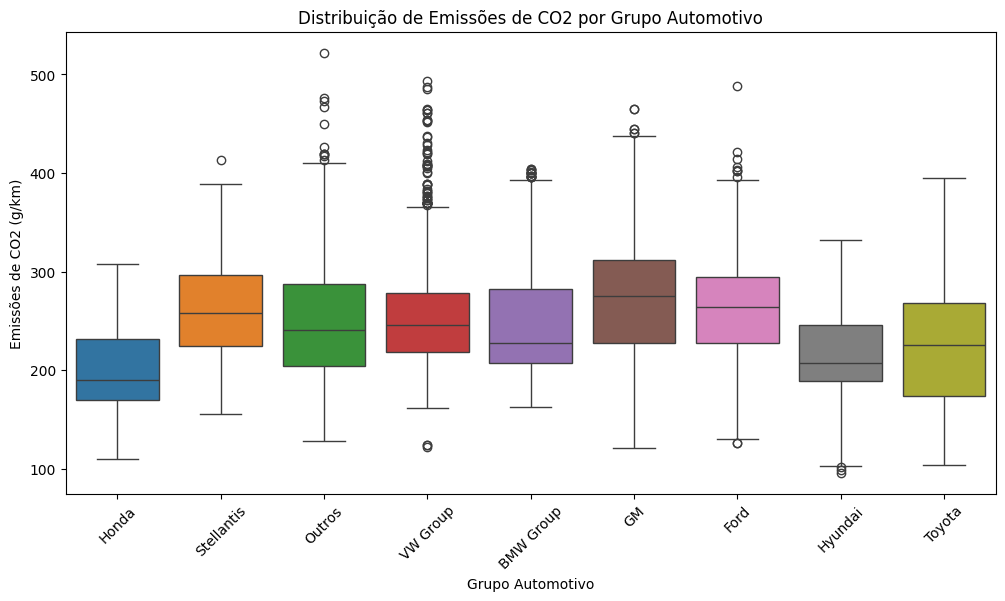

In [15]:
# Cria uma lista vazia, e um for que percorre a coluna de marcas
# Essa lista é preenchida conforme o grupo automotivo dos carros
lista_de_grupos = []
for marca in data['Make']:
    if marca in stellantis_marcas:
        lista_de_grupos.append('Stellantis')
    elif marca in gm_marcas:
        lista_de_grupos.append('GM')
    elif marca in vw_marcas:
        lista_de_grupos.append('VW Group')
    elif marca in toyota_marcas:
        lista_de_grupos.append('Toyota')
    elif marca in hyundai_marcas:
        lista_de_grupos.append('Hyundai')
    elif marca in bmw_marcas:
        lista_de_grupos.append('BMW Group')
    elif marca in ford_marcas:
        lista_de_grupos.append('Ford')
    elif marca in honda_marcas:
        lista_de_grupos.append('Honda')
    else:
        lista_de_grupos.append('Outros')

# Cria uma coluna no dataframe, com o grupo automotivo de cada carro
data['Grupo'] = lista_de_grupos

# Inicia a plotagem de vários boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Grupo',
    y='CO2 Emissions(g/km)',
    data=data,
    hue='Grupo',
    legend=False
)

plt.title('Distribuição de Emissões de CO2 por Grupo Automotivo')
plt.xticks(rotation=45)
plt.xlabel('Grupo Automotivo')
plt.ylabel('Emissões de CO2 (g/km)')
plt.show()

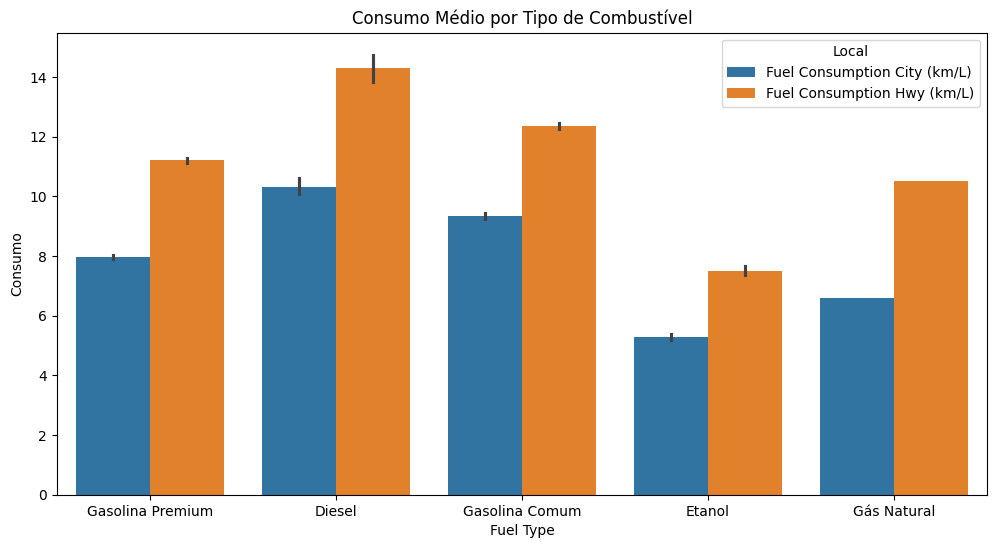

In [16]:
# Pega as colunas de consumo e empilhar uma embaixo da outra
data_plot = data.melt(id_vars='Fuel Type',
                     value_vars=['Fuel Consumption City (km/L)', 'Fuel Consumption Hwy (km/L)'],
                     var_name='Local',
                     value_name='Consumo')


# Inicia o plot de barras duplas
plt.figure(figsize=(12,6))

# x = Combustível
# y = O valor do consumo, que o Seaborn vai tirar a média
# Separa por Cidade ou Estrada usando a coluna 'Local'
sns.barplot(data=data_plot, x='Fuel Type', y='Consumo', hue='Local')

plt.title('Consumo Médio por Tipo de Combustível')
plt.show()

/tmp/ipykernel_242/1441733238.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20, x='CO2 Emissions(g/km)', y='Model', palette='Greens')


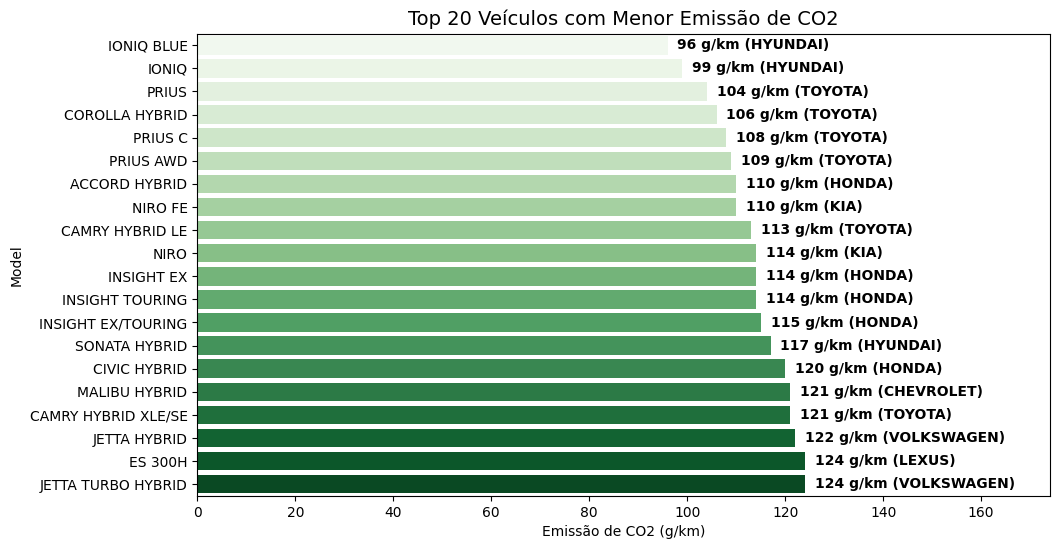

In [44]:
# Organiza do menor para o maior
data_ordenada = data.sort_values('CO2 Emissions(g/km)')

# Remove duplicatas de modelo, pra nao ficar redundante quando um carro tiver várias versões
top_20 = data_ordenada.drop_duplicates(subset='Model').head(20)

# Inicializa a plotagem
plt.figure(figsize=(11, 6))

sns.barplot(data=top_20, x='CO2 Emissions(g/km)', y='Model', palette='Greens')

plt.title('Top 20 Veículos com Menor Emissão de CO2', fontsize=14)
plt.xlabel('Emissão de CO2 (g/km)')

# Colocando os valores e a montadora na frente
for i, (idx, row) in enumerate(top_20.iterrows()):
    valor = row['CO2 Emissions(g/km)']
    marca = row['Make']
    plt.text(valor + 2, i, f"{int(valor)} g/km ({marca})", va='center', fontweight='bold')

plt.xlim(0, top_20['CO2 Emissions(g/km)'].max() + 50)
plt.show()

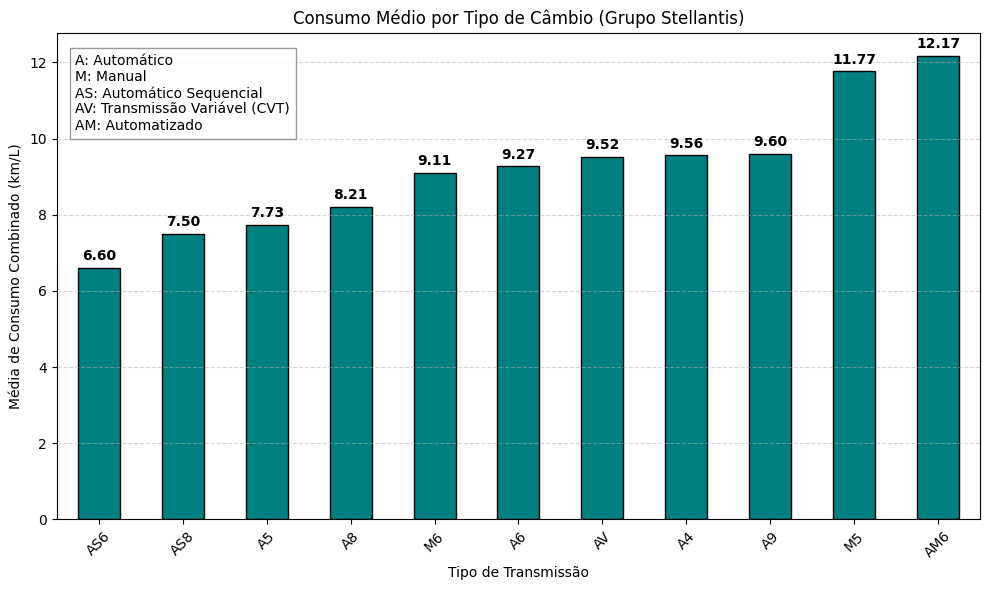

In [38]:
# Transformama as marcas para maiúsculo
data['Make_Lower'] = data['Make'].str.upper()

# Subconjunto de dados contendo apenas as marcas do grupo Stellantis
df_stellantis = data[data['Make_Lower'].isin(stellantis_marcas)]


# Ordena
media_cambio = df_stellantis.groupby('Transmission')['Fuel Consumption Comb (km/L)'].mean().sort_values()

# Inicia o plot
plt.figure(figsize=(10, 6))

media_cambio.plot(kind='bar', color='teal', edgecolor='black', rot=45)

plt.title('Consumo Médio por Tipo de Câmbio (Grupo Stellantis)')
plt.ylabel('Média de Consumo Combinado (km/L)')
plt.xlabel('Tipo de Transmissão')
plt.grid(axis='y', linestyle='--', alpha=0.5)


# Coloca o valor do consumo em cima da barra
for i, v in enumerate(media_cambio):

    plt.text(i, v + 0.2, f"{v:.2f}", ha='center', fontweight='bold')

# Legenda que será plotada posteriormente
legenda_explicativa = (
    "A: Automático\nM: Manual\nAS: Automático Sequencial\n"
    "AV: Transmissão Variável (CVT)\nAM: Automatizado"
)


# Plot da legenda
plt.text(0.02, 0.80, legenda_explicativa,
         transform=plt.gca().transAxes,
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.tight_layout()
plt.show()

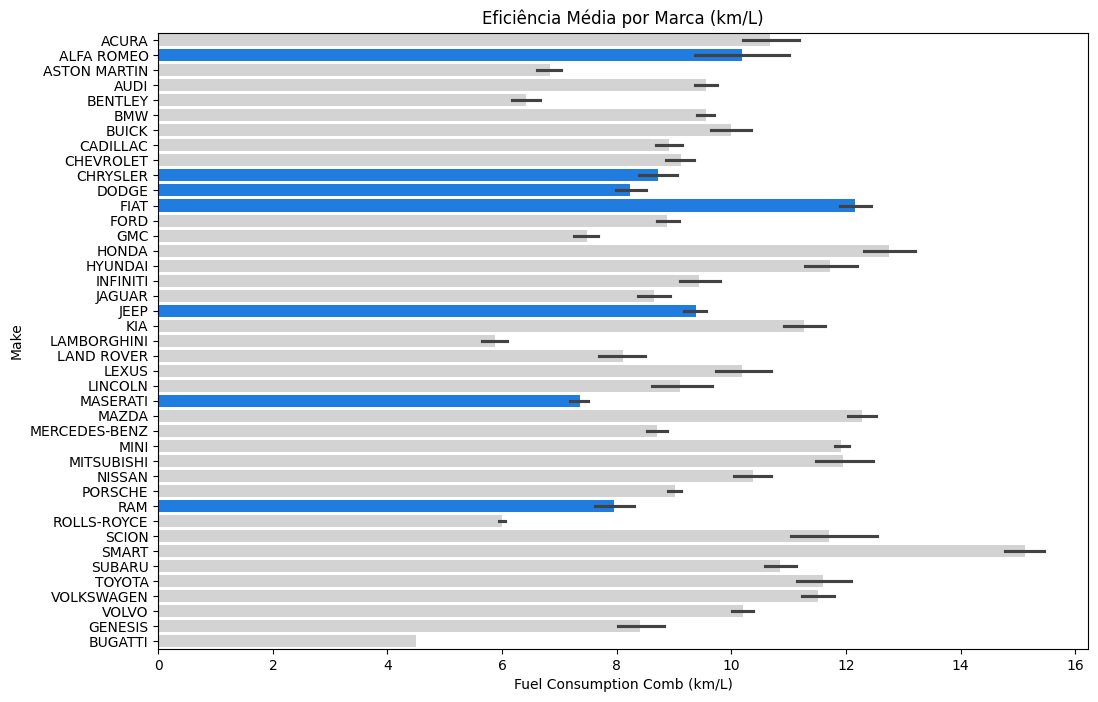

In [39]:
cores = {}
# Percorre a lista de marcas
for marca in lista_marcas:
    # Aplica a verificação se a marca está no grupo stellantes
    if marca in stellantis_marcas:
        cores[marca] = '#007bff'  # Cor Stellantis
    else:
        cores[marca] = '#d3d3d3'  # Cor Cinza (outras marcas)

# Inicia a plotagem
plt.figure(figsize=(12, 8))
sns.barplot(
    data=data,
    x='Fuel Consumption Comb (km/L)',
    y='Make',
    hue='Make',
    palette=cores,
    legend=False
)

plt.title('Eficiência Média por Marca (km/L)')
plt.show()


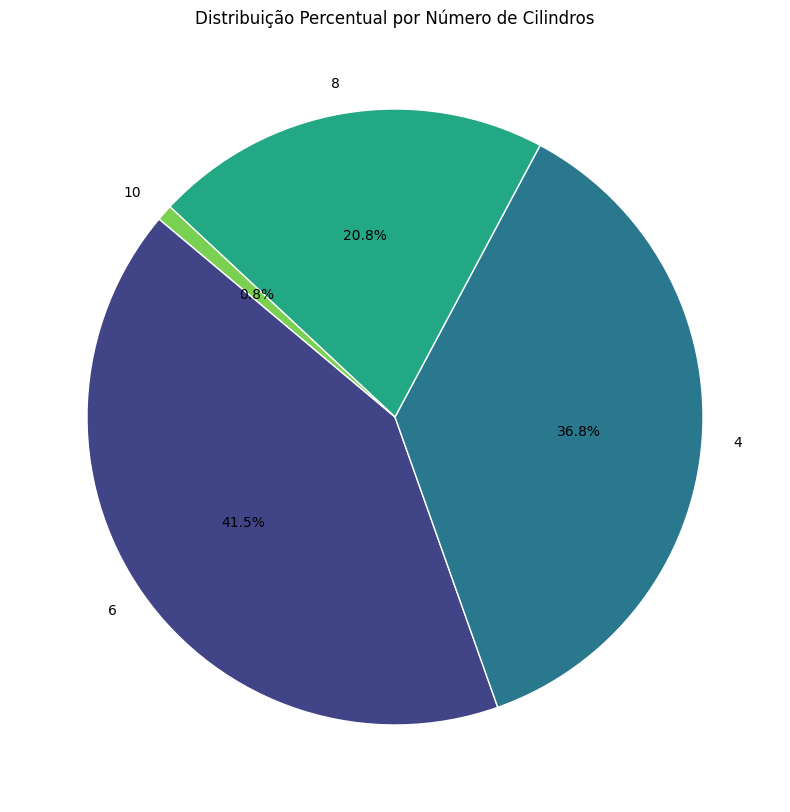

In [40]:
# Conta quantos veículos existem para cada quantidade de cilindros
contagem_cilindros = df_stellantis['Cylinders'].value_counts()

# Inicia a plotagem
plt.figure(figsize=(10, 10))
contagem_cilindros.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('viridis', len(contagem_cilindros)),
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Distribuição Percentual por Número de Cilindros')
plt.ylabel('')
plt.show()

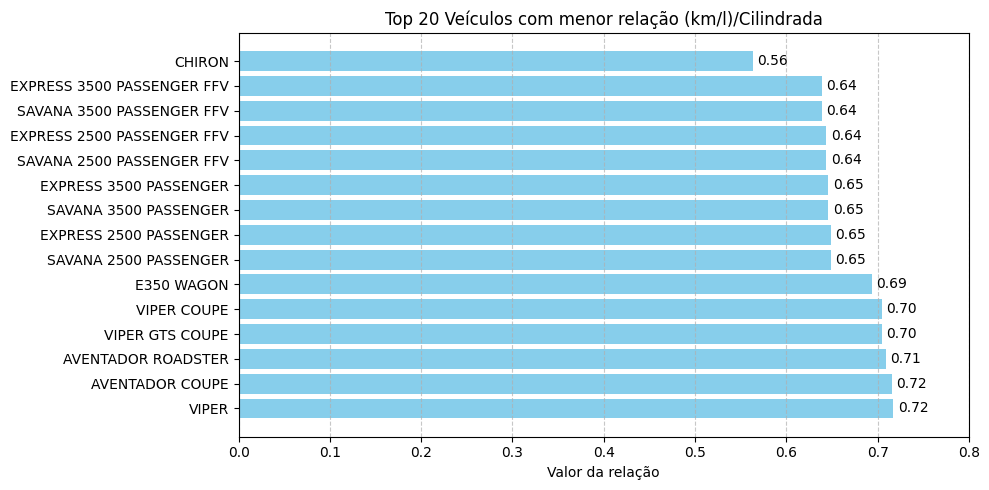

In [35]:
# data['EVE'] = data['Fuel Consumption Comb (km/L)'] / data['Engine Size(L)']

# top_5 = data.nsmallest(15, 'EVE')
# plt.figure(figsize=(10, 5))
# plt.barh(top_5['Model'], top_5['EVE'], color='skyblue')

# plt.xlabel('Valor da relação')
# plt.title('Top 20 Veículos com menor relação (km/l)/Cilindrada')
# plt.gca().invert_yaxis()
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.xlim(0, 0.8)\

# # Em vez de enumerate, percorremos o índice e o valor simultaneamente
# for i, (idx, v) in enumerate(top_5['EVE'].items()):
#     plt.text(v + 0.005, i, f"{v:.2f}", va='center')

# plt.tight_layout()
# plt.show()